In [11]:
from uncertainties import ufloat
from uncertainties import unumpy as unp
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

# Unsicherheiten



In [48]:

def str_to_ufloat(s):
    digits = len(s.split(".")[1])
    val = float(s)
    if digits == 2:
        # im 50v Bereich
        error = 0.0025 * val + 0.01

    elif digits == 3:
        error = 0.004 * val + 0.001
        # im 4v Bereich

    elif digits == 4:
        # im 400 mv Bereich 

        error = 0.0025 * val + 0.0005
    return ufloat(val, error)


Fehler_Vorspannung = 0.01

Spannung_UV = ["5.72","5.21","4.78","4.32","3.90","3.488","3.106","2.717","2.374","2.036","1.747","1.465","1.211","0.967","0.722","0.462","0.2642","0.1140","0.0152"]
Vorspannung_UV= [-0.1 * n for n in range(len(Spannung_UV))]
U_0_UV = "-0.0611" # Untergrundstrom


Spannung_Violett = ["6.19","5.72","5.24","4.78","4.26","3.84","3.405","2.972","2.590","2.209","1.866","1.557","1.249","0.958","0.703","0.439","0.2290","0.0904","0.0012"]
Vorspannung_Violett = [-0.1 * n + 0.3 for n in range(len(Spannung_Violett))]
U_0_Violett = "-0.0499"

Spannung_Blau = ["7.55","6.93","6.31","5.74","5.07","4.49","3.95","3.433","2.932","2.421","1.992","1.578","1.169","0.754","0.419","0.1544","0.0022"]
Vorspannung_Blau = [-0.1 * n + 0.3 for n in range(len(Spannung_Blau))]
U_0_Blau = "-0.0737"

Spannung_Grün = ["4.20","3.577","2.985","2.400","1.804","1.343","0.895","0.541","0.2695","0.1059","0.0242"]
Vorspannung_Grün = [-0.1 * n + 0.3 for n in range(len(Spannung_Grün))]
U_0_Grün = "-0.0293"

Spannung_Gelb = ["1.177","0.832","0.563","0.356","0.1998","0.1108","0.0644","0.0425"]
Vorspannung_Gelb = [-0.1 * n + 0.3 for n in range(len(Spannung_Gelb))]
U_0_Gelb = "-0.0135"


Messungen = [Spannung_UV, Spannung_Violett, Spannung_Blau, Spannung_Grün, Spannung_Gelb]
Vorspannungen = [Vorspannung_UV, Vorspannung_Violett, Vorspannung_Blau, Vorspannung_Grün, Vorspannung_Gelb]
Dunkelspannungen = [U_0_UV, U_0_Blau,U_0_Blau, U_0_Grün, U_0_Gelb]

def map_str_to_ufloat(a): return [str_to_ufloat(x) for x in a]


Dunkelspannungen = map_str_to_ufloat(Dunkelspannungen)
Vorspannungen = [[ufloat(x,0.01) for x in a] for a in Vorspannungen]
Messungen = [map_str_to_ufloat(a) for a in Messungen]

def arrayu_to_uarray(a):
    return unp.uarray([x.nominal_value for x in a], [x.std_dev for x in a])

Vorspannungen = [arrayu_to_uarray(a) for a in Vorspannungen]
Messungen = [arrayu_to_uarray(a) for a in Messungen]


# Abzug der Dunkelspannnug 
Messungen = [Messungen[i] - Dunkelspannungen[i] for i in range(len(Dunkelspannungen))]

# Wurzel ziehen
Messungen = [unp.sqrt(m) for m in Messungen]




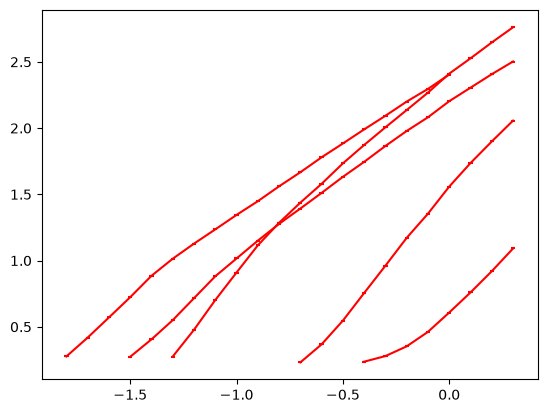

In [47]:
def nom(x):return unp.nominal_values(x)
def std(x): return unp.std_devs(x)
for i in range(5):
    plt.errorbar(nom(Vorspannungen[i]),nom(Messungen[i]),std(Messungen[i]),std(Vorspannungen[i]),fmt="r")
    #plt.show()